--- Starting Pre-processing ---
Processed data saved to processed_adv_stats_4vars_final.csv
x = 2.15 m: tau_near_bed = 0.000737, u* = 0.027142
x = 3.65 m: tau_near_bed = 0.000548, u* = 0.023405
x = 5.15 m: tau_near_bed = 0.000353, u* = 0.018800

Estimated friction velocity u* (from tau) = 0.02311581594059052

--- Training XGBoost ---
XGBoost Done (0.80 s)

--- Generating XGBoost Plots ---


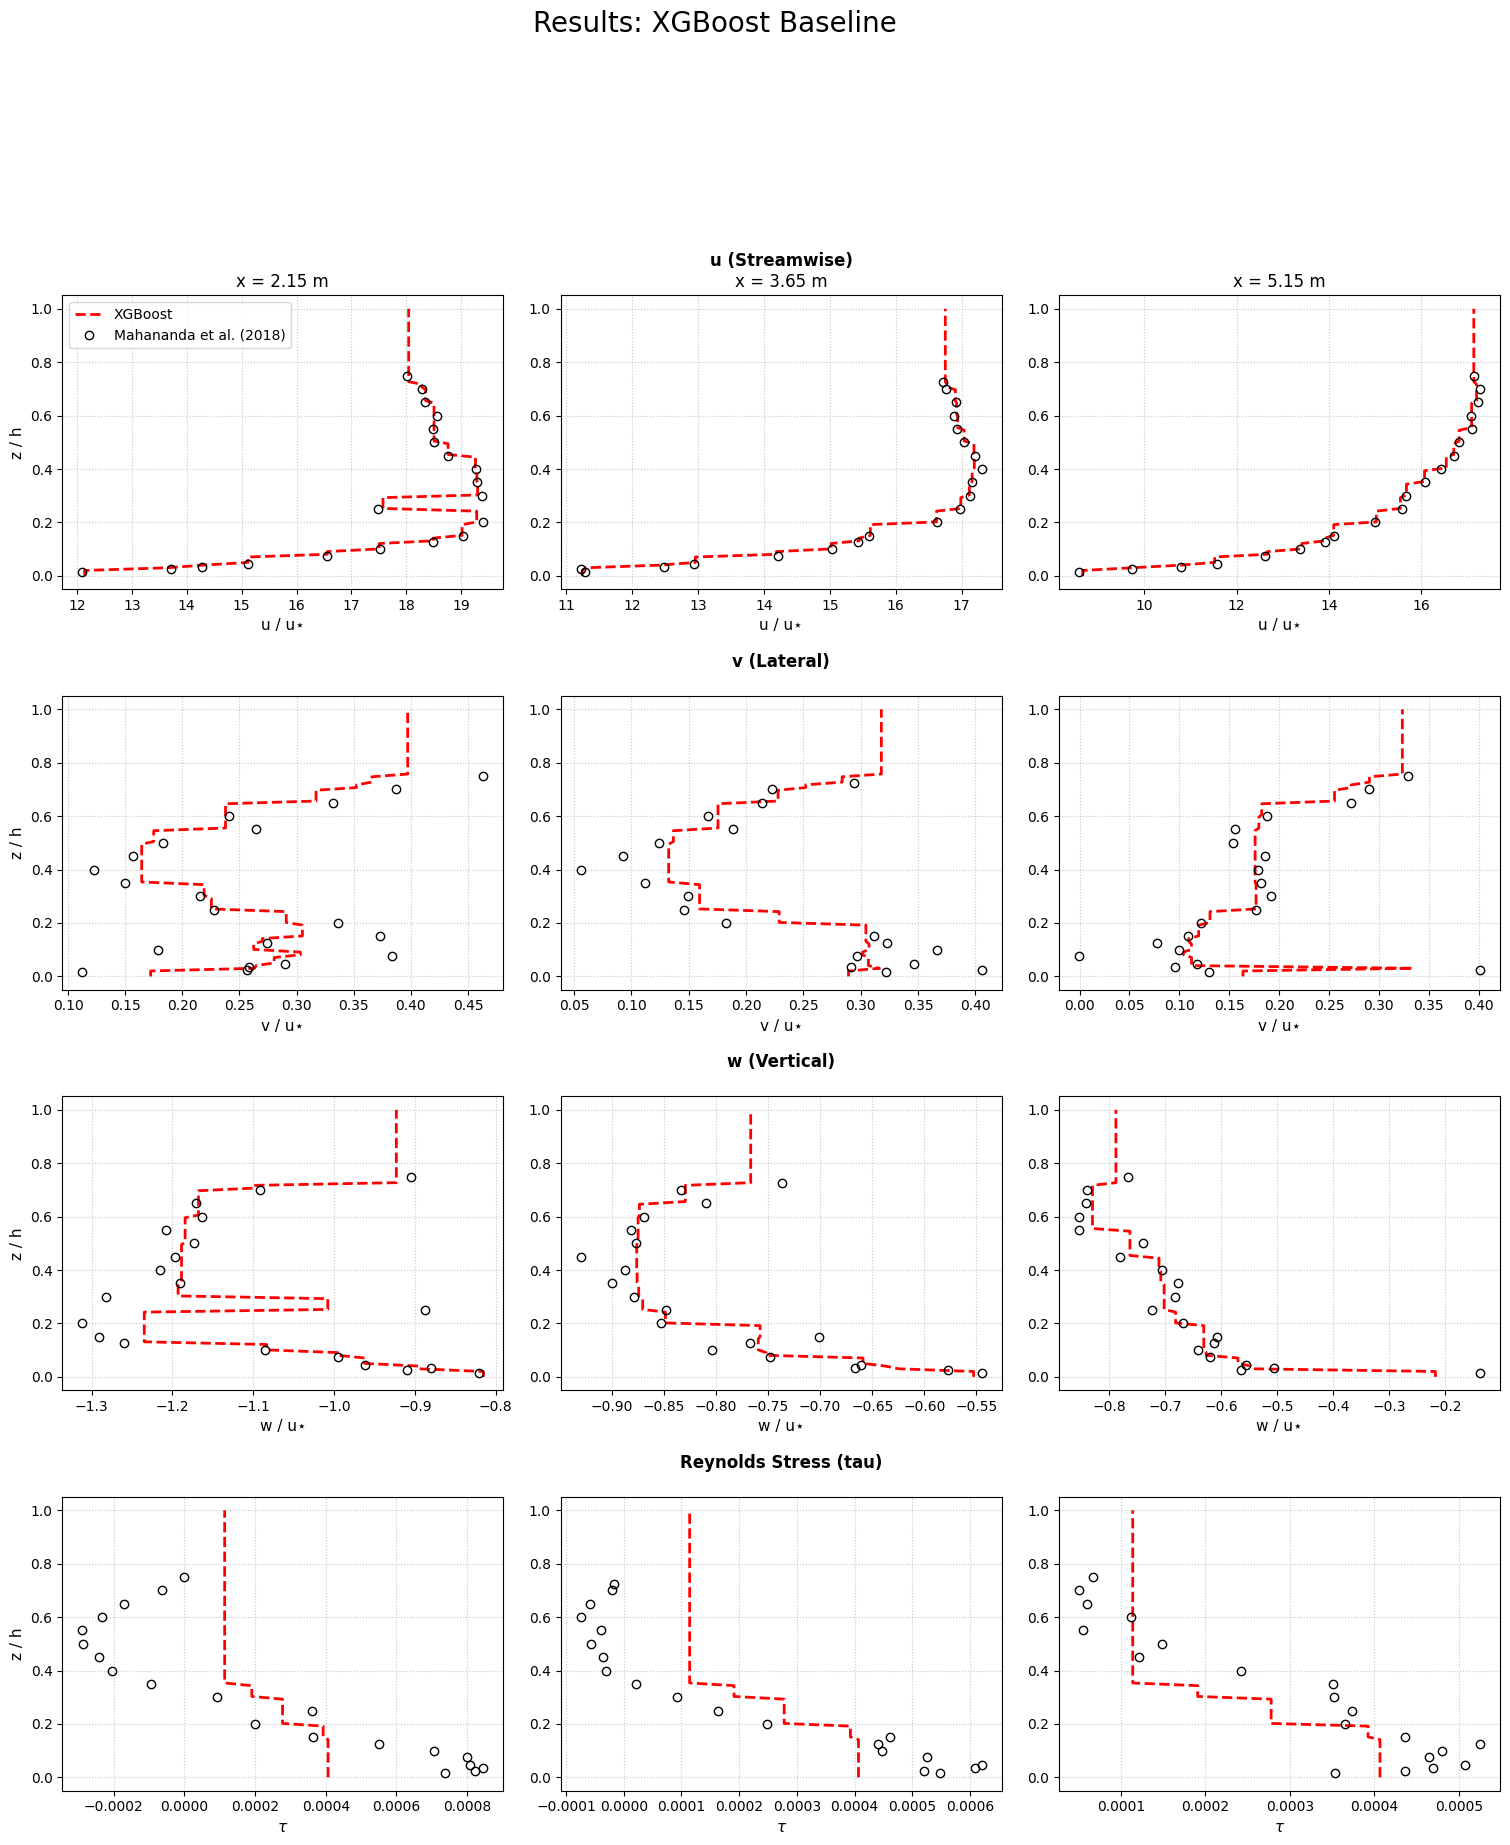


--- XGBOOST ACCURACY (R2 Score) ---
u   : 99.97%
v   : 87.07%
w   : 98.03%
tau : 58.85%
----------------
AVG : 85.98%


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
import time
import os

# =============================================================================
# --- (A) Parameters ---
# =============================================================================
INLET_VELOCITY = 0.37
L_channel, W_channel, H_channel = 7.0, 0.6, 0.2
X_MIN = np.array([0.0, 0.0, 0.0], dtype=np.float32)
X_MAX = np.array([L_channel, W_channel, H_channel], dtype=np.float32)

RAW_DATA_FILE = '/kaggle/input/processed2/raw data.xlsx'
PROCESSED_DATA_FILE = 'processed_adv_stats_4vars_final.csv'

# =============================================================================
# Step 1: Pre-processing (u, v, w, tau)
# =============================================================================
def process_raw_data(raw_excel_file, processed_csv_file):
    print("--- Starting Pre-processing ---")
    try:
        xl = pd.ExcelFile(raw_excel_file)
        sheet_mapping = {'x=2.15m': 2.15, 'x=3.65m': 3.65, 'x=5.15m': 5.15}
        all_sheets_data = []

        for sheet_name, x_value in sheet_mapping.items():
            if sheet_name not in xl.sheet_names:
                print(f"Skipping {sheet_name}: not in workbook")
                continue

            df_sheet = pd.read_excel(xl, sheet_name=sheet_name)

            col_map = {
                'depth (m)': 'z',
                'AvgVx (m/s)': 'u',
                'AvgVy (m/s)': 'v',
                'AvgVz (m/s)': 'w',
                'ReynoldsStress uw': 'tau'
            }

            missing = [key for key in col_map.keys() if key not in df_sheet.columns]
            if missing:
                print(f"Skipping {sheet_name}: missing columns {missing}")
                continue

            df_sub = df_sheet[list(col_map.keys())].copy()
            for c in df_sub.columns:
                df_sub[c] = pd.to_numeric(df_sub[c], errors='coerce')
            df_sub.dropna(inplace=True)

            df_proc = df_sub.rename(columns=col_map)
            df_proc['x'] = x_value
            df_proc['y'] = W_channel / 2.0  # mid-width

            all_sheets_data.append(df_proc)

        if not all_sheets_data:
            print("No valid sheets found.")
            return None

        df_final = pd.concat(all_sheets_data, ignore_index=True)
        df_final = df_final[['x', 'y', 'z', 'u', 'v', 'w', 'tau']]
        df_final.to_csv(processed_csv_file, index=False)
        print(f"Processed data saved to {processed_csv_file}")
        return df_final

    except Exception as e:
        print("Error in processing:", e)
        return None


# remove previous processed file if exists
if os.path.exists(PROCESSED_DATA_FILE):
    os.remove(PROCESSED_DATA_FILE)

df_processed = process_raw_data(RAW_DATA_FILE, PROCESSED_DATA_FILE)
if df_processed is None:
    raise ValueError("Data processing failed. Check RAW_DATA_FILE path and sheet names.")

# =============================================================================
# Step 1b: Estimate friction velocity u_* from near-bed tau
# =============================================================================
u_star_values = []
x_unique = sorted(df_processed['x'].unique())

for x_val in x_unique:
    df_x = df_processed[np.isclose(df_processed['x'], x_val)]
    df_x = df_x.sort_values('z')  # lowest z = closest to bed
    tau_near_bed = df_x['tau'].iloc[0]
    u_star_local = np.sqrt(abs(tau_near_bed))
    u_star_values.append(u_star_local)
    print(f"x = {x_val} m: tau_near_bed = {tau_near_bed:.6f}, u* = {u_star_local:.6f}")

U_STAR = float(np.mean(u_star_values))
print("\nEstimated friction velocity u* (from tau) =", U_STAR)

# =============================================================================
# Step 2: Build input and target arrays
# =============================================================================
X_np = df_processed[['x', 'y', 'z']].values.astype(np.float32)
Y_train_xgb = df_processed[['u', 'v', 'w', 'tau']].values.astype(np.float32)

# =============================================================================
# Step 3: Train XGBoost
# =============================================================================
print("\n--- Training XGBoost ---")
xgb_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=8,
        n_jobs=-1
    )
)

start_time = time.time()
xgb_model.fit(X_np, Y_train_xgb)
print(f"XGBoost Done ({time.time() - start_time:.2f} s)")

# =============================================================================
# Step 4: Plotting Results (XGBoost Only, u/u*, v/u*, w/u*)
# =============================================================================
print("\n--- Generating XGBoost Plots ---")
x_locs = [2.15, 3.65, 5.15]
z_smooth = np.linspace(0.0, H_channel, 100).astype(np.float32)

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Results: XGBoost Baseline", fontsize=20, y=0.97)

titles = ['u (Streamwise)', 'v (Lateral)', 'w (Vertical)', 'Reynolds Stress (tau)']
targets = ['u', 'v', 'w', 'tau']

# Axis labels using friction velocity u_*
axis_labels = [
    r'u / u⋆',
    r'v / u⋆',
    r'w / u⋆',
    r'$\tau$'
]

for j, x_val in enumerate(x_locs):
    # Input Grid for Plotting
    x_grid = np.full_like(z_smooth, x_val)
    y_grid = np.full_like(z_smooth, W_channel / 2.0)
    X_in_np = np.stack([x_grid, y_grid, z_smooth], axis=1)

    # Predictions
    pred_xgb = xgb_model.predict(X_in_np)

    # Experimental Data at this x
    df_exp = df_processed[np.isclose(df_processed['x'], x_val)]
    z_exp = df_exp['z'] / H_channel

    # Variables for plotting
    vars_xgb = [pred_xgb[:, i] for i in range(4)]
    vars_exp = [df_exp[k].values for k in targets]

    # Normalise velocities by u*, tau stays dimensional
    norm_factors = [U_STAR] * 3 + [1.0]

    for row in range(4):
        ax = axes[row, j]

        # XGBoost: red dashed line
        ax.plot(
            vars_xgb[row] / norm_factors[row],
            z_smooth / H_channel,
            'r--',
            linewidth=2.0,
            label='XGBoost'
        )

        # Experimental: black circular markers
        ax.plot(
            vars_exp[row] / norm_factors[row],
            z_exp,
            'ko',
            markersize=6,
            mfc='none',
            label='Mahananda et al. (2018)'
        )

        # Y label only on first column
        if j == 0:
            ax.set_ylabel("z / h", fontsize=11)

        # X label on all plots
        ax.set_xlabel(f"{axis_labels[row]}", fontsize=11)

        # Column and row titles
        if row == 0:
            ax.set_title(f"x = {x_val} m", fontsize=12)

        if j == 1:
            ax.text(
                0.5, 1.10, titles[row],
                ha='center',
                transform=ax.transAxes,
                fontsize=12,
                fontweight='bold'
            )

        if j == 0 and row == 0:
            ax.legend()

        ax.grid(True, linestyle=':', alpha=0.7)
        ax.title.set_y(1.04)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.88])
plt.show()

# =============================================================================
# Step 5: Accuracy Calculation
# =============================================================================
print("\n--- XGBOOST ACCURACY (R2 Score) ---")
out_xgb_train = xgb_model.predict(X_np)

xgb_preds = {
    'u': out_xgb_train[:, 0],
    'v': out_xgb_train[:, 1],
    'w': out_xgb_train[:, 2],
    'tau': out_xgb_train[:, 3]
}

truths = {
    'u': df_processed['u'].values,
    'v': df_processed['v'].values,
    'w': df_processed['w'].values,
    'tau': df_processed['tau'].values
}

accuracies = []
for key in ['u', 'v', 'w', 'tau']:
    score = r2_score(truths[key], xgb_preds[key]) * 100
    accuracies.append(score)
    print(f"{key:4}: {score:.2f}%")

print("----------------")
print(f"AVG : {np.mean(accuracies):.2f}%")


TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
--- Starting Pre-processing ---
x = 2.15 m: tau_near_bed = 0.000737, u* = 0.027142
x = 3.65 m: tau_near_bed = 0.000548, u* = 0.023405
x = 5.15 m: tau_near_bed = 0.000353, u* = 0.018800

Estimated friction velocity u* (from tau) = 0.02311581594059052

--- STARTING 4-VAR TRAINING ---
Epoch 2000/8000 | Loss: 0.064331
Epoch 4000/8000 | Loss: 0.036098
Epoch 6000/8000 | Loss: 0.032209
Epoch 8000/8000 | Loss: 0.019589
Training Finished in 41.1s

--- Generating Final PINN Plots ---


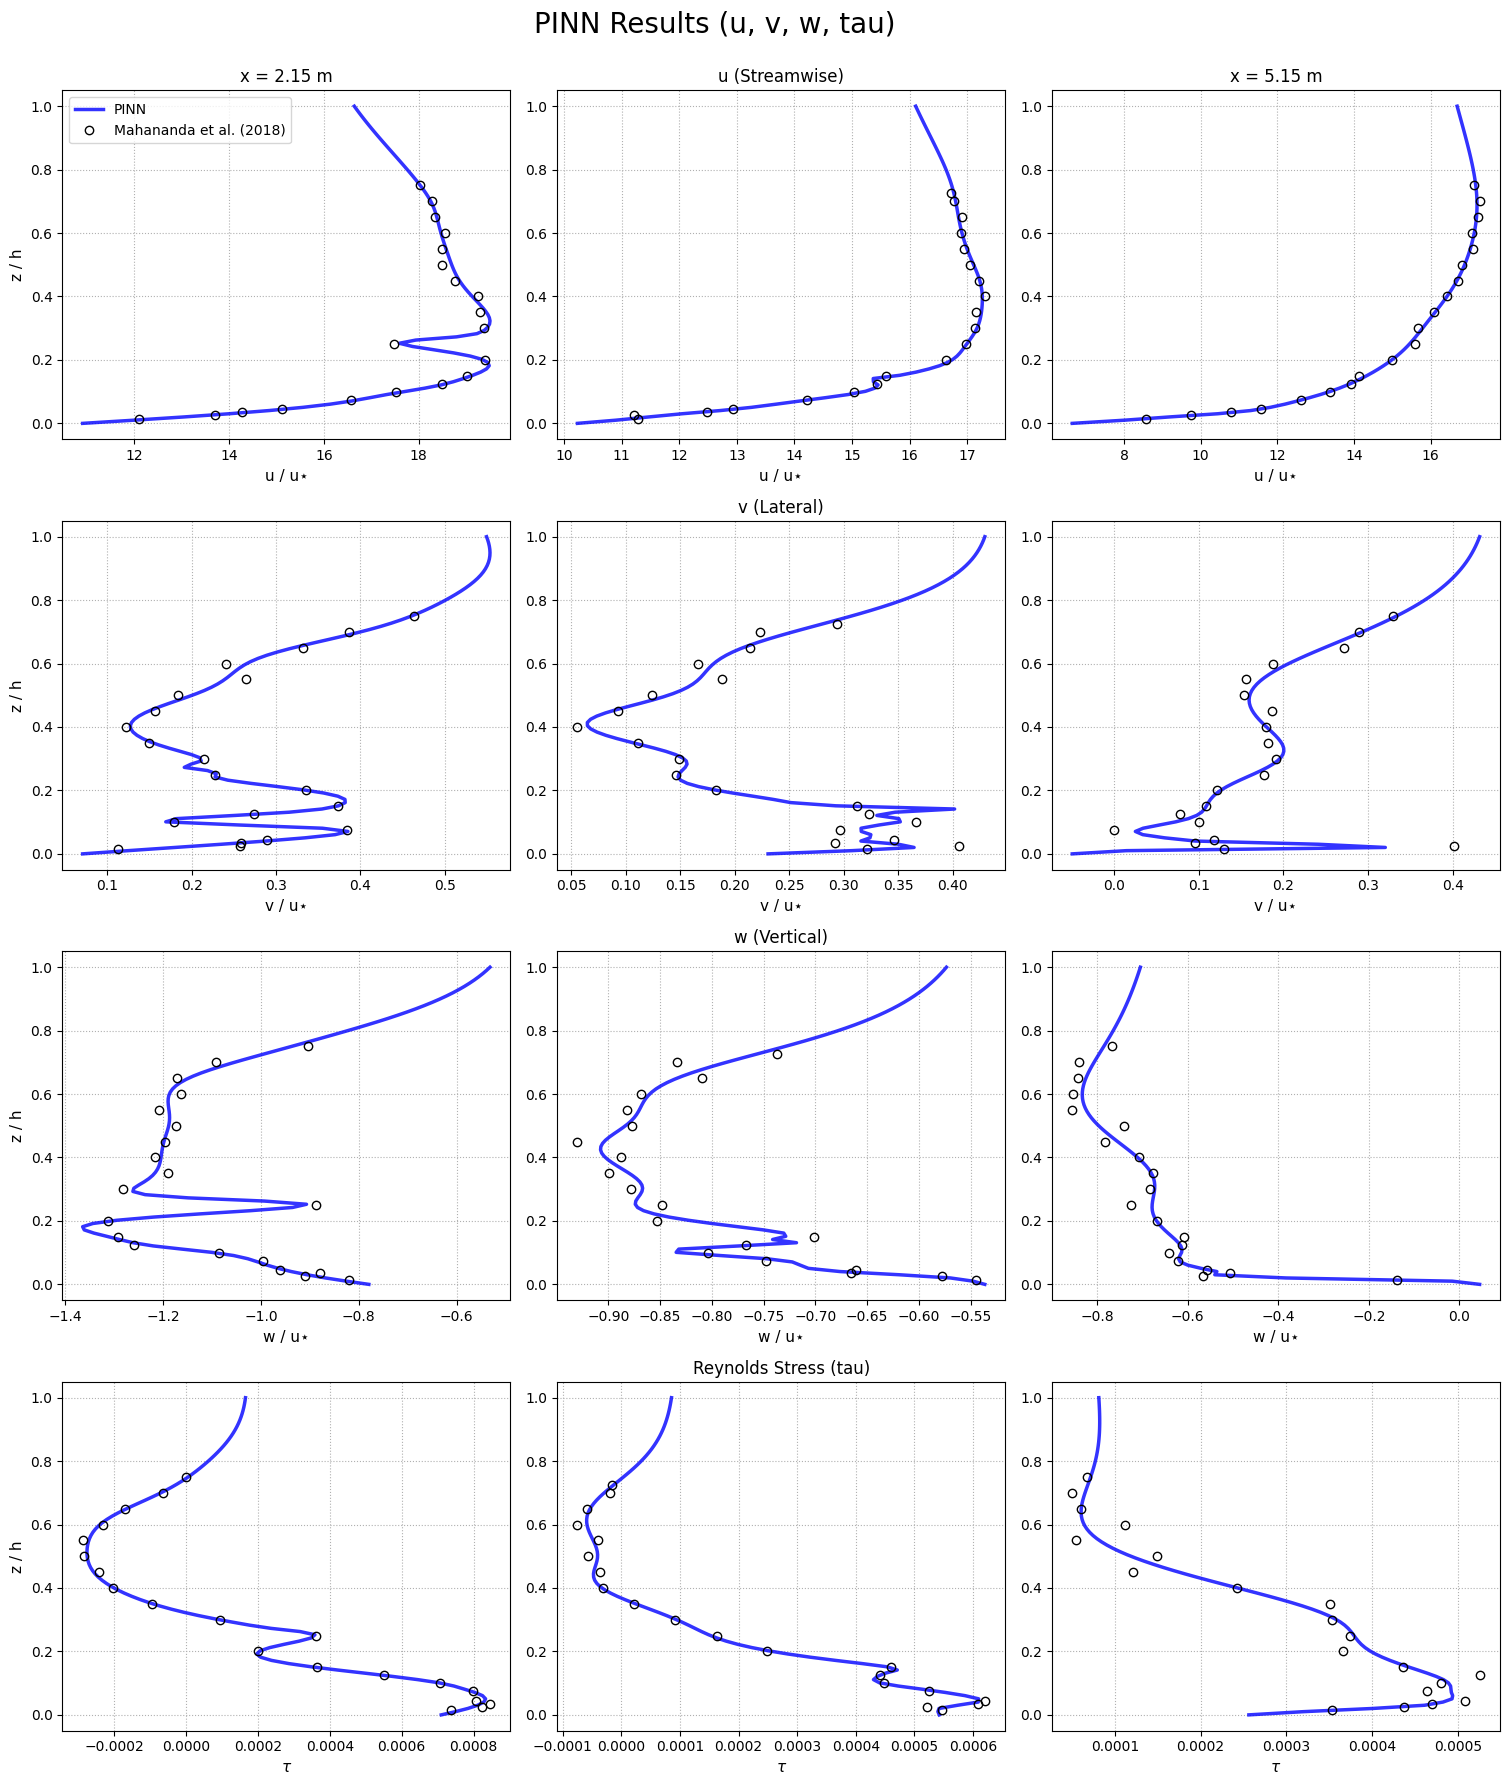


--- MODEL ACCURACY (R2 Score on full dataset) ---
  u:     99.75%
  v:     96.56%
  w:     98.93%
  tau:   99.64%
---------------------------
  AVERAGE: 98.72%


In [13]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from sklearn.metrics import r2_score

# Set data type
DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# =============================================================================
# --- (A) Parameters ---
# =============================================================================
INLET_VELOCITY = 0.37
L_channel, W_channel, H_channel = 7.0, 0.6, 0.2
X_MIN = tf.constant([0.0, 0.0, 0.0], dtype=DTYPE)
X_MAX = tf.constant([L_channel, W_channel, H_channel], dtype=DTYPE)

RAW_DATA_FILE = '/kaggle/input/processed2/raw data.xlsx'
PROCESSED_DATA_FILE = 'processed_adv_stats_4vars_final.csv'
EPSILON = 1e-8

# =============================================================================
# Step 1: Pre-processing (Strictly u, v, w, tau)
# =============================================================================
def process_raw_data(raw_excel_file, processed_csv_file):
    print("--- Starting Pre-processing ---")
    try:
        xl = pd.ExcelFile(raw_excel_file)
        sheet_mapping = {'x=2.15m': 2.15, 'x=3.65m': 3.65, 'x=5.15m': 5.15}
        all_sheets_data = []

        for sheet_name, x_value in sheet_mapping.items():
            if sheet_name not in xl.sheet_names:
                continue
            df_sheet = pd.read_excel(xl, sheet_name=sheet_name)

            col_map = {
                'depth (m)': 'z',
                'AvgVx (m/s)': 'u',
                'AvgVy (m/s)': 'v',
                'AvgVz (m/s)': 'w',
                'ReynoldsStress uw': 'tau'
            }

            missing = [key for key in col_map.keys() if key not in df_sheet.columns]
            if missing:
                print(f"Skipping {sheet_name}: Missing columns {missing}")
                continue

            df_sub = df_sheet[list(col_map.keys())].copy()
            for c in df_sub.columns:
                df_sub[c] = pd.to_numeric(df_sub[c], errors='coerce')
            df_sub.dropna(inplace=True)

            df_proc = df_sub.rename(columns=col_map)
            df_proc['x'] = x_value
            df_proc['y'] = W_channel / 2.0

            all_sheets_data.append(df_proc)

        if not all_sheets_data:
            return None
        df_final = pd.concat(all_sheets_data, ignore_index=True)
        df_final = df_final[['x', 'y', 'z', 'u', 'v', 'w', 'tau']]
        df_final.to_csv(processed_csv_file, index=False)
        return df_final
    except Exception as e:
        print(f"Error: {e}")
        return None

if os.path.exists(PROCESSED_DATA_FILE):
    os.remove(PROCESSED_DATA_FILE)
df_processed = process_raw_data(RAW_DATA_FILE, PROCESSED_DATA_FILE)
if df_processed is None:
    raise ValueError("Data failed.")

# =============================================================================
# Step 1b: Estimate friction velocity u_* from near-bed tau
# =============================================================================
u_star_values = []
x_unique = sorted(df_processed['x'].unique())

for x_val in x_unique:
    df_x = df_processed[np.isclose(df_processed['x'], x_val)]
    df_x = df_x.sort_values('z')   # lowest z = near bed
    tau_near_bed = df_x['tau'].iloc[0]
    u_star_local = np.sqrt(abs(tau_near_bed))
    u_star_values.append(u_star_local)
    print(f"x = {x_val} m: tau_near_bed = {tau_near_bed:.6f}, u* = {u_star_local:.6f}")

U_STAR = float(np.mean(u_star_values))
print("\nEstimated friction velocity u* (from tau) =", U_STAR)

# Scales
scales = {
    'u': df_processed['u'].abs().max() + 1e-6,
    'v': df_processed['v'].abs().max() + 1e-6,
    'w': df_processed['w'].abs().max() + 1e-6,
    'tau': df_processed['tau'].abs().max() + 1e-6
}

X_data_np = df_processed[['x', 'y', 'z']].values.astype(np.float32)
Y_data_np = np.stack([
    (df_processed['u'].values / scales['u']).astype(np.float32),
    (df_processed['v'].values / scales['v']).astype(np.float32),
    (df_processed['w'].values / scales['w']).astype(np.float32),
    (df_processed['tau'].values / scales['tau']).astype(np.float32)
], axis=1)

X_data = tf.convert_to_tensor(X_data_np, dtype=DTYPE)
Y_train = tf.convert_to_tensor(Y_data_np, dtype=DTYPE)

# =============================================================================
# Step 2: The Network
# =============================================================================
class DensePINN(tf.keras.Model):
    def __init__(self, name="PINN"):
        super().__init__(name=name)
        self.norm_layer = tf.keras.layers.Lambda(
            lambda x: 2.0 * (x - X_MIN) / (X_MAX - X_MIN) - 1.0
        )

        self.hidden_layers = []
        for _ in range(8):
            self.hidden_layers.append(tf.keras.layers.Dense(
                128,
                activation='tanh',
                kernel_initializer='glorot_normal',
                kernel_regularizer=tf.keras.regularizers.l2(1e-4)
            ))

        self.out_layer = tf.keras.layers.Dense(4, kernel_initializer='glorot_normal')

    def call(self, x):
        x = self.norm_layer(x)
        for layer in self.hidden_layers:
            x = layer(x)
        return self.out_layer(x)

model = DensePINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

# =============================================================================
# Step 3: Training Step
# =============================================================================
@tf.function
def train_step(X_batch, Y_batch):
    with tf.GradientTape() as tape:
        out_raw = model(X_batch)

        mse_u   = tf.reduce_mean(tf.square(Y_batch[:, 0] - out_raw[:, 0]))
        mse_v   = tf.reduce_mean(tf.square(Y_batch[:, 1] - out_raw[:, 1]))
        mse_w   = tf.reduce_mean(tf.square(Y_batch[:, 2] - out_raw[:, 2]))
        mse_tau = tf.reduce_mean(tf.square(Y_batch[:, 3] - out_raw[:, 3]))

        w_u   = 1.2
        w_v   = 1.2
        w_w   = 1.0
        w_tau = 1.5

        data_loss = (
            w_u * mse_u +
            w_v * mse_v +
            w_w * mse_w +
            w_tau * mse_tau
        )

        loss_reg = tf.add_n(model.losses)

        loss_total = data_loss + loss_reg

    grads = tape.gradient(loss_total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_total

# =============================================================================
# Step 4: Execution (train on full data)
# =============================================================================
ds = tf.data.Dataset.from_tensor_slices((X_data, Y_train)).shuffle(1000).batch(64).repeat()
ds_iter = iter(ds)

print("\n--- STARTING 4-VAR TRAINING ---")
EPOCHS = 8000
start_time = time.time()

for i in range(EPOCHS):
    X_b, Y_b = next(ds_iter)
    loss = train_step(X_b, Y_b)
    if (i + 1) % 2000 == 0:
        print(f"Epoch {i+1}/{EPOCHS} | Loss: {loss:.6f}")

print(f"Training Finished in {time.time() - start_time:.1f}s")

# =============================================================================
# Step 5: Plotting Results (u/u*, v/u*, w/u*)
# =============================================================================
print("\n--- Generating Final PINN Plots ---")
x_locs = [2.15, 3.65, 5.15]
z_smooth = np.linspace(0.0, H_channel, 100).astype(np.float32)
z_tensor = tf.reshape(z_smooth, (-1, 1))
y_tensor = tf.ones_like(z_tensor) * (W_channel / 2)

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("PINN Results (u, v, w, tau)", fontsize=20, y=0.92)
titles = ['u (Streamwise)', 'v (Lateral)', 'w (Vertical)', 'Reynolds Stress (tau)']

xlabels = [
    r'u / u⋆',
    r'v / u⋆',
    r'w / u⋆',
    r'$\tau$'
]

for j, x_val in enumerate(x_locs):
    x_tensor = tf.ones_like(z_tensor) * x_val
    X_in = tf.concat([x_tensor, y_tensor, z_tensor], axis=1)

    out = model(X_in)
    u_p = out[:, 0].numpy() * scales['u']
    v_p = out[:, 1].numpy() * scales['v']
    w_p = out[:, 2].numpy() * scales['w']
    tau_p = out[:, 3].numpy() * scales['tau']

    df_exp = df_processed[np.isclose(df_processed['x'], x_val)]
    z_exp = df_exp['z'] / H_channel

    data_p = [u_p, v_p, w_p, tau_p]
    data_e = [df_exp['u'], df_exp['v'], df_exp['w'], df_exp['tau']]

    norm_factors = [U_STAR] * 3 + [1.0]

    for row in range(4):
        ax = axes[row, j]
        ax.plot(
            data_p[row] / norm_factors[row],
            z_smooth / H_channel,
            'b-',
            linewidth=2.5,
            alpha=0.8,
            label='PINN'
        )
        ax.plot(
            data_e[row] / norm_factors[row],
            z_exp,
            'ko',
            markersize=6,
            mfc='none',
            label='Mahananda et al. (2018)'
        )

        if j == 0:
            ax.set_ylabel("z / h", fontsize=11)
        ax.set_xlabel(f"{xlabels[row]}", fontsize=11)

        if row == 0:
            ax.set_title(f'x = {x_val} m')
        if j == 1:
            ax.set_title(titles[row])

        if j == 0 and row == 0:
            ax.legend()
        ax.grid(True, linestyle=':')

plt.tight_layout(rect=[0.05, 0.03, 1, 0.92])
plt.show()

# =============================================================================
# Step 6: Accuracy Calculation (on full data)
# =============================================================================
print("\n--- MODEL ACCURACY (R2 Score on full dataset) ---")
out_all = model(X_data).numpy()

u_p_all = out_all[:, 0] * scales['u']
v_p_all = out_all[:, 1] * scales['v']
w_p_all = out_all[:, 2] * scales['w']
tau_p_all = out_all[:, 3] * scales['tau']

r2_u = r2_score(df_processed['u'], u_p_all)
r2_v = r2_score(df_processed['v'], v_p_all)
r2_w = r2_score(df_processed['w'], w_p_all)
r2_tau = r2_score(df_processed['tau'], tau_p_all)

print(f"  u:     {r2_u*100:.2f}%")
print(f"  v:     {r2_v*100:.2f}%")
print(f"  w:     {r2_w*100:.2f}%")
print(f"  tau:   {r2_tau*100:.2f}%")
print("---------------------------")
print(f"  AVERAGE: {np.mean([r2_u, r2_v, r2_w, r2_tau])*100:.2f}%")
